# SVM for classification

Load IRIS dataset, check its contents:


In [ ]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [ ]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [ ]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

1.0

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [14]:
from sklearn import datasets

#select only the first two features
iris=datasets.load_iris()
X, y=iris.data[:, :3], iris. target


# Keep only classes 0 and 1
X, y = X[y < 2], y[y < 2]


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# train SVM with linear kernel
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)


# accuracy
print("Model accuracy:", svm_model. score(X_test, y_test))



Model accuracy: 1.0


Plot scatterplots of targets 0 and 1 and check the separability of the classes:

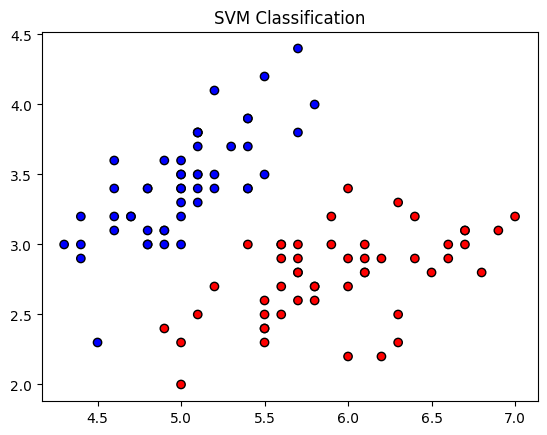

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
plt.scatter (X[:, 0], X[:, 1], c=y, cmap='bwr' , edgecolors='k')
plt.title("SVM Classification")
plt.show()


Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

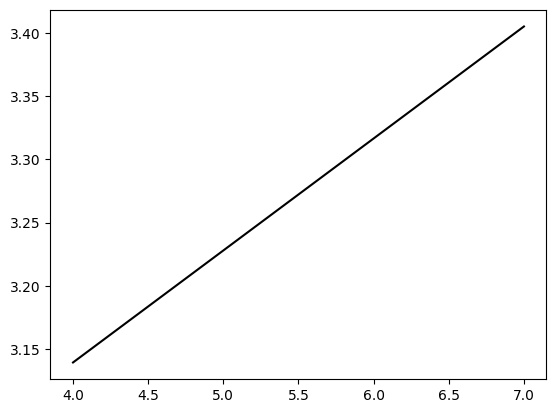

In [22]:
supvectors=SVMmodel.support_vectors_
# Plot the support vectors here




#Separating line coefficients:
W=SVMmodel.coef_[0]
a=-W[0]/W[1]
b=SVMmodel.intercept_[0]/W[1]
xx=np.linspace(4,7)
yy=a*xx+b
plt.plot(xx,yy,'k-')
plt.show()


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

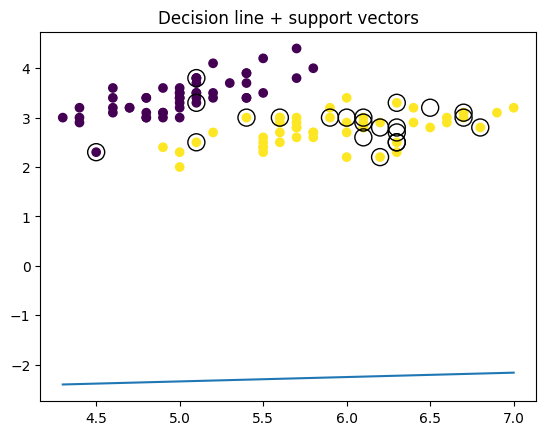

In [21]:
import numpy as np

supvectors = SVMmodel.support_vectors_

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(supvectors[:, 0], supvectors[:, 1], s=150, facecolors='none', edgecolors='k')

w = SVMmodel.coef_[0]
b = SVMmodel.intercept_[0]

x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
y_line = -(w[0] * x_line + b) / w[1]

plt.plot(x_line, y_line)
plt.title("Decision line + support vectors")
plt.show()




# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

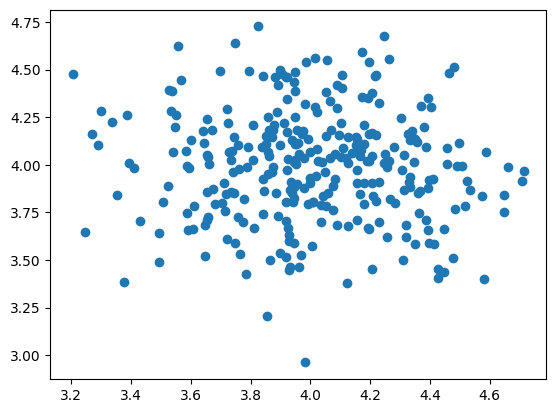

In [24]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random


random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))


plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

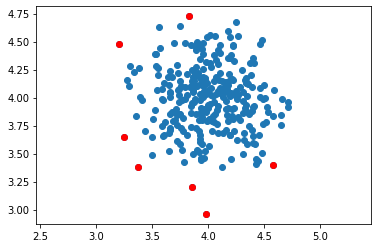

In [ ]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

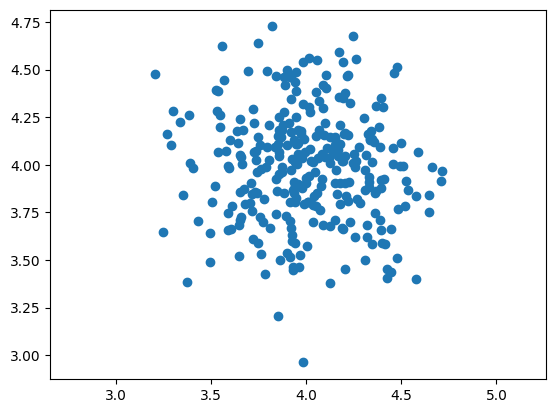

In [25]:

import numpy as np
import matplotlib.pyplot as plt


from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random


random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))


plt.scatter(x[:, 0], x[:, 1])
plt.axis("equal")
plt.show()



What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

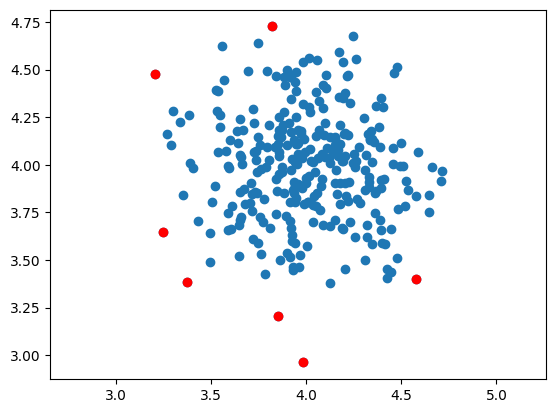

In [19]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)

SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)

anom_index = where(pred == -1)
values = x[anom_index]

plt.scatter(x[:, 0], x[:, 1])
plt.scatter(values[:, 0], values[:, 1], color='red')
plt.axis('equal')
plt.show()

